In [1]:
import numpy as np

SEED = 42

import torch
import torchvision

from torch import nn

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

In [2]:
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor()
])

data_train = torchvision.datasets.MNIST(root='data/', train=True, download=True, transform=transform)
data_test = torchvision.datasets.MNIST(root='data/', train=False, download=True, transform=transform)

train_dataloader = torch.utils.data.DataLoader(data_train, shuffle=True, batch_size=32)
test_dataloader = torch.utils.data.DataLoader(data_test, shuffle=False, batch_size=32)

In [3]:
_, width, height = data_train.data.shape

In [4]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

In [5]:
class MLP(nn.Module):
    def __init__(self, ):
        super(MLP, self).__init__()

        self.layer1 = nn.Linear(width * height, 16)
        self.activation1 = nn.Sigmoid()
        self.layer2 = nn.Linear(16, 10)

    def forward(self, x):
        x = torch.flatten(x, 1)
        hidden = self.activation1(self.layer1(x))
        return self.layer2(hidden)

In [6]:
model = MLP().to(device)

model = torch.jit.script(model)

In [7]:
x, y = next(iter(train_dataloader))
x = x.to(device)
y = y.to(device)

model.forward(x).shape

torch.Size([32, 10])

In [8]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1.0e-3)

In [9]:
n_epochs = 16
n_iterations = len(train_dataloader)

model.train()
model.zero_grad()

losses = np.ndarray(shape=(n_epochs, n_iterations))

for i in tqdm(range(n_epochs)):
    for j, (x, y) in tqdm(enumerate(train_dataloader), total=len(train_dataloader), leave=False):
        model.zero_grad()

        x = x.to(device)
        y = y.to(device)

        predictions = model.forward(x)
        loss = loss_fn(predictions, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        losses[i, j] = loss.item()

  0%|          | 0/16 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

...

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

  0%|          | 0/1875 [00:00<?, ?it/s]

In [10]:
def plot_losses(losses, n_bands=4):
    epochs = np.arange(losses.shape[0])
    bands = np.quantile(losses, q=np.linspace(0, 1, num=2 * n_bands + 3)[1:-1], axis=1)
    
    fig = plt.figure(figsize=(9, 6))
    axes = fig.subplots(1, 1)
    
    for i in range(n_bands):
        axes.fill_between(epochs, bands[i], bands[-i - 1], alpha=0.2, color=plt.cm.tab10(0))
    
    axes.plot(epochs, bands[n_bands])

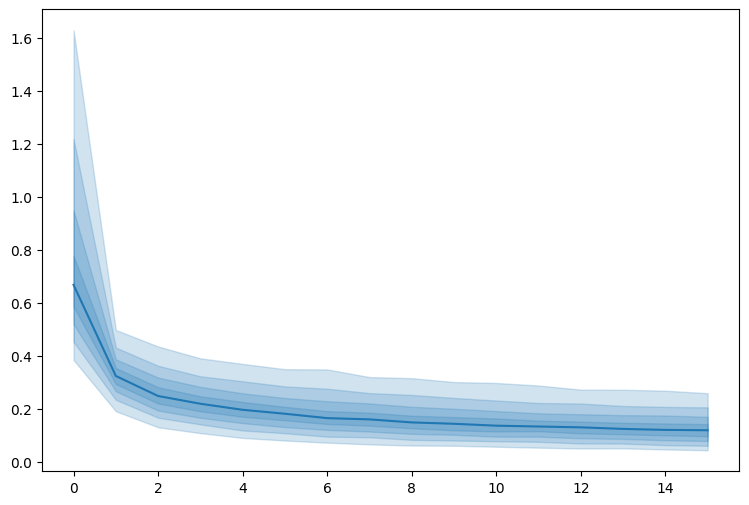

In [11]:
plot_losses(losses)

In [12]:
accuracy = 0

model.eval()
for x, y in tqdm(test_dataloader, total=len(test_dataloader)):
    x, y = x.to(device), y.to(device)

    predictions = model.forward(x)
    best_class = torch.argmax(predictions, axis=1)
    accuracy += torch.sum(best_class == y).item()

accuracy /= test_dataloader.dataset.data.shape[0]

  0%|          | 0/313 [00:00<?, ?it/s]

In [13]:
print(accuracy)

0.9518


In [14]:
W = model.layer1.weight.detach().cpu().numpy()

In [15]:
W.shape

(16, 784)

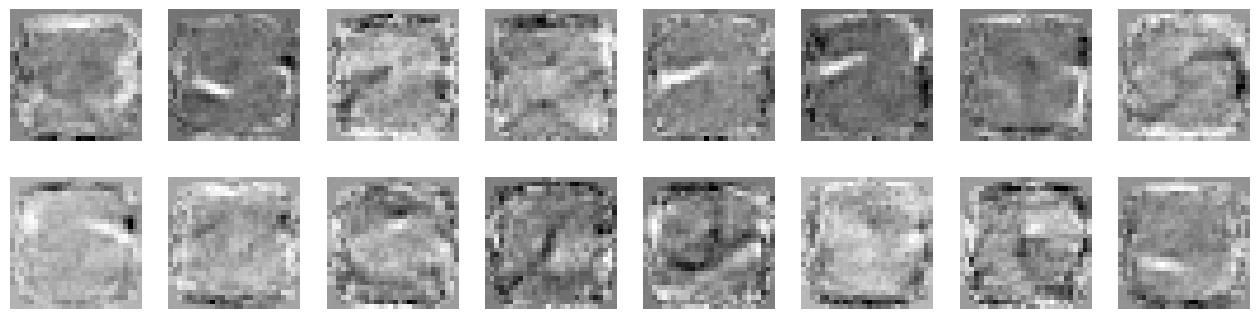

In [16]:
fig = plt.figure(figsize=(16, 4))
axes = fig.subplots(2, 8, squeeze=False).ravel()

for i in range(W.shape[0]):
    axes[i].imshow(W[i].reshape((width, height)), cmap=plt.cm.Grays)
    axes[i].axis('off')